# CREDIT RISK DATASET

## 1. Importar librerías y *Credit Risk Dataset*

In [68]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json

# Preprocesamiento y partición de datos
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

# Pipeline, preprocesamiento y búsqueda de hiperparámetros
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# Métricas de evaluación
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    make_scorer,
)

# Visualización LaTeX en notebook
from IPython.display import display, Math

In [69]:
df = pd.read_csv(r"C:\Users\usuario\OneDrive\Proyectos\TFG\credit_risk_dataset.csv")

## 2. Análisis exploratorio

In [70]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [71]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [73]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [74]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [75]:
df.nunique()

person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  348
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
dtype: int64

In [76]:
# Eliminar registros con person_age > 90 y person_emp_length == 123
print(f"Registros antes: {len(df)}")
df = df[df['person_age'] <= 90]
df = df[df['person_emp_length'] != 123]
print(f"Registros después: {len(df)}")

Registros antes: 32581
Registros después: 32573


## 3. Modelos de clasificación

Se entrenan tres modelos de clasificación (**Regresión Logística**, **K-NN** y **Árbol de Clasificación**) siguiendo el siguiente esquema:

- **División train/test**: 80 % / 20 %, estratificada por `loan_status` y `random_state=42`.
- **Validación cruzada**: 5 *folds* estratificados sobre el conjunto de entrenamiento.
- **Métrica de selección**: AUC.
- **Preprocesamiento**:
  - Imputación de valores faltantes en `person_emp_length` y `loan_int_rate` con `KNNImputer` (k=5).
  - `StandardScaler` sobre las variables cuantitativas únicamente para el K-NN.
  - `OneHotEncoder` con `drop='first'` para la Regresión Logística (categoría de referencia) y `drop=None` para K-NN y Árbol (todas las dummies).

Para cada modelo se reportan, con la mejor combinación de hiperparámetros, las medias en CV de AUC, exactitud, tasa de error, precisión, sensibilidad, especificidad y F1-Score, y se reentrena el estimador ganador sobre todo el conjunto de entrenamiento.

### 3.1. División train/test

In [77]:
# Separar features y target
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# División train/test (80/20, estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean()*100:.2f}% default)")
print(f"Test:  {X_test.shape[0]} registros ({y_test.mean()*100:.2f}% default)")

Train: 26058 registros (21.82% default)
Test:  6515 registros (21.81% default)


### 3.2. Pipelines de preprocesamiento

Se definen **tres** `ColumnTransformer`, uno por modelo, para aplicar el preprocesado más adecuado a cada algoritmo:

| Preprocessor | Imputación | Escalado | OneHot `drop` | Usado por |
|---|---|---|---|---|
| `preprocessor_lr` | KNNImputer(k=5) | — | `'first'` | Regresión Logística |
| `preprocessor_knn` | KNNImputer(k=5) | **StandardScaler** | `None` | K-NN |
| `preprocessor_dt` | KNNImputer(k=5) | — | `None` | Árbol de Clasificación |

In [78]:
# Columnas numéricas y categóricas
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length']

cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade',
            'cb_person_default_on_file']

# Pipelines numéricos
num_pipeline_scaled = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])
num_pipeline_unscaled = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5))
])

# Pipelines categóricos 
cat_pipeline_lr = Pipeline([
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])
cat_pipeline_knn = Pipeline([
    ('encoder', OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False))
])
cat_pipeline_dt = Pipeline([
    ('encoder', OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformers por modelo
preprocessor_lr = ColumnTransformer([
    ('num', num_pipeline_unscaled, num_cols),
    ('cat', cat_pipeline_lr, cat_cols)
])
preprocessor_knn = ColumnTransformer([
    ('num', num_pipeline_scaled, num_cols),
    ('cat', cat_pipeline_knn, cat_cols)
])
preprocessor_dt = ColumnTransformer([
    ('num', num_pipeline_unscaled, num_cols),
    ('cat', cat_pipeline_dt, cat_cols)
])

### 3.3. Esquema de validación cruzada y métricas

In [79]:
# Especificidad 
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

# Tasa de error
def error_rate_score(y_true, y_pred):
    return 1 - accuracy_score(y_true, y_pred)

# Diccionario de métricas
scoring = {
    'AUC':           'roc_auc',
    'Exactitud':     'accuracy',
    'Tasa de error': make_scorer(error_rate_score),
    'Precisión':     'precision',
    'Sensibilidad':  'recall',
    'Especificidad': make_scorer(specificity_score),
    'F1-Score':      'f1'
}

# Estrategia de CV: 5 folds estratificados
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 3.4. Regresión Logística

Se entrena una regresión logística **sin penalización** (`C=np.inf`). No hay hiperparámetros que ajustar por validación cruzada: simplemente se estiman los coeficientes con el solver 'lbfgs' y se reportan las métricas medias en 5-fold CV.

In [80]:
# Regresión Logística 
lr_pipe = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(C=np.inf, max_iter=2000, random_state=42))
])

# Hiperparámetros fijos 
lr_best_params = {'penalty': None, 'solver': 'lbfgs', 'max_iter': 2000}

# Validación cruzada (5 folds) con todas las métricas
lr_cv = cross_validate(lr_pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
lr_metrics = {m: lr_cv[f'test_{m}'].mean() for m in scoring}

print("=== Regresión Logística ===")
print(f"Hiperparámetros: {lr_best_params}")
print("\nMétricas medias (5-fold CV):")
for m, v in lr_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

# Reentrenar sobre todo el conjunto de entrenamiento
lr_pipe.fit(X_train, y_train)
print("\n→ Modelo reentrenado sobre todo X_train.")

# Guardar hiperparámetros en JSON
with open('lr_best_params.json', 'w') as f:
    json.dump(lr_best_params, f, indent=4)
print("→ Hiperparámetros guardados en lr_best_params.json")

=== Regresión Logística ===
Hiperparámetros: {'penalty': None, 'solver': 'lbfgs', 'max_iter': 2000}

Métricas medias (5-fold CV):
  AUC           : 0.8541
  Exactitud     : 0.8485
  Tasa de error : 0.1515
  Precisión     : 0.7515
  Sensibilidad  : 0.4562
  Especificidad : 0.9580
  F1-Score      : 0.5675


c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(



→ Modelo reentrenado sobre todo X_train.
→ Hiperparámetros guardados en lr_best_params.json


c:\Users\usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [81]:
# Definición lr_model, coefs e intercept para Odds Ratios
lr_prep = lr_pipe.named_steps['preprocessor']
ohe_lr  = lr_prep.named_transformers_['cat'].named_steps['encoder']
cat_feature_names_lr = list(ohe_lr.get_feature_names_out(cat_cols))
feature_names = num_cols + cat_feature_names_lr

lr_model  = lr_pipe.named_steps['classifier']
coefs     = lr_model.coef_[0]
intercept = lr_model.intercept_[0]

In [88]:
# Tabla de los Odds Ratios
or_df = pd.DataFrame({
    'Variable':         feature_names,
    'Coeficiente (b)':  np.round(coefs, 4),
    'Odds Ratio (e^b)': np.round(np.exp(coefs), 4)
}).sort_values('Odds Ratio (e^b)', ascending=False).reset_index(drop=True)
or_df.index += 1

print(f'Intercepto (b₀): {intercept:.4f}\n')
or_df

Intercepto (b₀): -1.8241



,Variable,Coeficiente (b),Odds Ratio (e^b)
1,loan_grade_E,1.4923,4.4473
2,loan_percent_income,1.4426,4.2318
3,loan_grade_D,1.0147,2.7585
4,person_home_ownership_RENT,0.7567,2.1313
5,loan_grade_F,0.6787,1.9712
6,loan_grade_G,0.3694,1.4468
7,cb_person_default_on_file_Y,0.1771,1.1937
8,loan_int_rate,0.1630,1.1770
9,person_home_ownership_OTHER,0.0642,1.0663
10,loan_intent_HOMEIMPROVEMENT,0.0263,1.0266


#### Inferencia estadística de los coeficientes

La tabla anterior cuantifica la magnitud y dirección del efecto de cada variable a través de los *Odds Ratios*, pero no responde a si dicho efecto es **estadísticamente significativo** o si podría deberse al azar muestral. Como `scikit-learn` no proporciona inferencia sobre los coeficientes, se reajusta el mismo modelo (sin penalización, sobre las mismas variables tras el preprocesado) con la librería `statsmodels`, que sí aporta los errores estándar, el estadístico de Wald ($z$), los p-valores y los intervalos de confianza al $95\,\%$ para cada $OR$.

Adicionalmente, se reportan métricas globales de bondad de ajuste: la **log-verosimilitud** del modelo ajustado y la del modelo nulo (solo intercepto), el **test de razón de verosimilitudes (LR test)** global, el **pseudo-$R^2$ de McFadden** y los criterios **AIC/BIC**.

In [89]:
# Inferencia estadística sobre los coeficientes con statsmodels
import statsmodels.api as sm

# Aplicamos al X_train el mismo preprocesado de la regresión logística (sin escalar)
X_train_lr = pd.DataFrame(lr_prep.transform(X_train), columns=feature_names)
y_train_lr = y_train.reset_index(drop=True)

# Ajuste de la logística (sin penalización) con statsmodels
X_sm = sm.add_constant(X_train_lr, has_constant='add')
sm_logit = sm.Logit(y_train_lr, X_sm).fit(disp=0, maxiter=500)

# Métricas globales de bondad de ajuste
print(f"Log-verosimilitud:        {sm_logit.llf:.2f}")
print(f"Log-verosimilitud nula:   {sm_logit.llnull:.2f}")
print(f"Test LR global:           LLR = {sm_logit.llr:.2f}, p = {sm_logit.llr_pvalue:.2e}")
print(f"Pseudo-R² de McFadden:    {sm_logit.prsquared:.4f}")
print(f"AIC: {sm_logit.aic:.2f}   |   BIC: {sm_logit.bic:.2f}\n")

# Tabla con coeficiente, error estándar, z de Wald, p-valor, OR e IC95% del OR
ci = sm_logit.conf_int(alpha=0.05)
ci.columns = ['CI_low', 'CI_high']

inference_df = pd.DataFrame({
    'Variable':       sm_logit.params.index,
    'Coef (b)':       sm_logit.params.values.round(4),
    'Error est.':     sm_logit.bse.values.round(4),
    'z (Wald)':       sm_logit.tvalues.values.round(3),
    'p-valor':        sm_logit.pvalues.values,
    'OR (e^b)':       np.exp(sm_logit.params.values).round(4),
    'OR IC95% inf':   np.exp(ci['CI_low'].values).round(4),
    'OR IC95% sup':   np.exp(ci['CI_high'].values).round(4),
    'Significativa':  np.where(sm_logit.pvalues.values < 0.05, '✓', '✗')
})

# Movemos el intercepto al principio y ordenamos el resto por OR descendente
intercept_row = inference_df[inference_df['Variable'] == 'const']
rest          = inference_df[inference_df['Variable'] != 'const'].sort_values('OR (e^b)', ascending=False)
inference_df  = pd.concat([intercept_row, rest], ignore_index=True)
inference_df.index = range(len(inference_df))

# Formateamos el p-valor en notación científica
inference_df.style.format({'p-valor': '{:.3e}'})

Log-verosimilitud:        -8789.34
Log-verosimilitud nula:   -13670.74
Test LR global:           LLR = 9762.79, p = 0.00e+00
Pseudo-R² de McFadden:    0.3571
AIC: 17624.69   |   BIC: 17812.55



,Variable,Coef (b),Error est.,z (Wald),p-valor,OR (e^b),OR IC95% inf,OR IC95% sup,Significativa
0,const,-4.130300,0.191300,-21.594000,2.056e-103,0.016100,0.011100,0.023400,✓
1,loan_percent_income,13.808300,0.297100,46.484000,0.000e+00,992784.345000,554631.150700,1777074.285300,✓
2,loan_grade_G,6.645500,1.042500,6.374000,1.839e-10,769.277900,99.692700,5936.129000,✓
3,loan_grade_F,3.187000,0.233300,13.660000,1.767e-42,24.216200,15.328800,38.256500,✓
4,loan_grade_E,2.724600,0.157400,17.309000,4.036e-67,15.249800,11.201600,20.761200,✓
5,loan_grade_D,2.511700,0.120200,20.894000,6.071e-97,12.325900,9.738600,15.600700,✓
6,person_home_ownership_RENT,0.838500,0.045100,18.592000,3.715e-77,2.312900,2.117200,2.526600,✓
7,loan_grade_C,0.413500,0.098400,4.201000,2.663e-05,1.512100,1.246800,1.833900,✓
8,person_home_ownership_OTHER,0.251500,0.318800,0.789000,4.303e-01,1.285900,0.688300,2.402200,✗
9,loan_grade_B,0.203100,0.069900,2.905000,3.677e-03,1.225200,1.068300,1.405100,✓


### 3.5. K-NN

Búsqueda en cuadrícula (`GridSearchCV`) de la mejor combinación de:
- `n_neighbors` ∈ {3, 5, 7, 9, 11, 15, 21, 31, 51, 101}
- `weights` ∈ {'uniform', 'distance'}
- `metric` ∈ {'euclidean', 'manhattan'}

In [83]:
# K-NN
knn_pipe = Pipeline([
    ('preprocessor', preprocessor_knn),
    ('classifier', KNeighborsClassifier())
])

# Se prueba con 40 combinaciones de hiperparámetros
knn_params = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31, 51, 101],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    knn_pipe, knn_params,
    cv=cv, scoring=scoring, refit='AUC',
    n_jobs=12, verbose=1
)
knn_grid.fit(X_train, y_train)

# Mejor combinación y métricas asociadas (medias de los 5 folds)
knn_best_idx = knn_grid.best_index_
knn_best_params = {k.replace('classifier__', ''): v for k, v in knn_grid.best_params_.items()}
knn_metrics = {m: knn_grid.cv_results_[f'mean_test_{m}'][knn_best_idx] for m in scoring}

print("=== K-NN ===")
print(f"Mejores hiperparámetros: {knn_best_params}")
print("\nMétricas medias (5-fold CV) con la mejor combinación:")
for m, v in knn_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

print("\n→ Modelo reentrenado sobre todo X_train (refit='AUC').")

# Guardar hiperparámetros en JSON
with open('knn_best_params.json', 'w') as f:
    json.dump(knn_best_params, f, indent=4)
print("→ Hiperparámetros guardados en knn_best_params.json")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
=== K-NN ===
Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 31, 'weights': 'distance'}

Métricas medias (5-fold CV) con la mejor combinación:
  AUC           : 0.8997
  Exactitud     : 0.8977
  Tasa de error : 0.1023
  Precisión     : 0.9196
  Sensibilidad  : 0.5821
  Especificidad : 0.9858
  F1-Score      : 0.7129

→ Modelo reentrenado sobre todo X_train (refit='AUC').
→ Hiperparámetros guardados en knn_best_params.json


#### Curva AUC frente a $k$

Fijada la mejor combinación de hiperparámetros secundarios (`weights='distance'`, `metric='manhattan'`), se representa el AUC medio en validación cruzada en función del número de vecinos $k$. Esta curva permite visualizar empíricamente el **dilema sesgo-varianza** discutido en la Sección 2.4: valores muy pequeños de $k$ generan modelos de alta varianza (sobreajustan al ruido del *train*), mientras que valores muy grandes incrementan el sesgo (suavizan en exceso la frontera de decisión). El óptimo se sitúa en el valor de $k$ que minimiza el error en CV.

Curva AUC vs k  (weights='distance', metric='manhattan')

  k  mean_test_AUC  std_test_AUC
  3         0.8540        0.0037
  5         0.8723        0.0033
  7         0.8825        0.0029
  9         0.8862        0.0030
 11         0.8891        0.0030
 15         0.8930        0.0027
 21         0.8976        0.0026
 31         0.8997        0.0029
 51         0.8995        0.0026
101         0.8975        0.0039


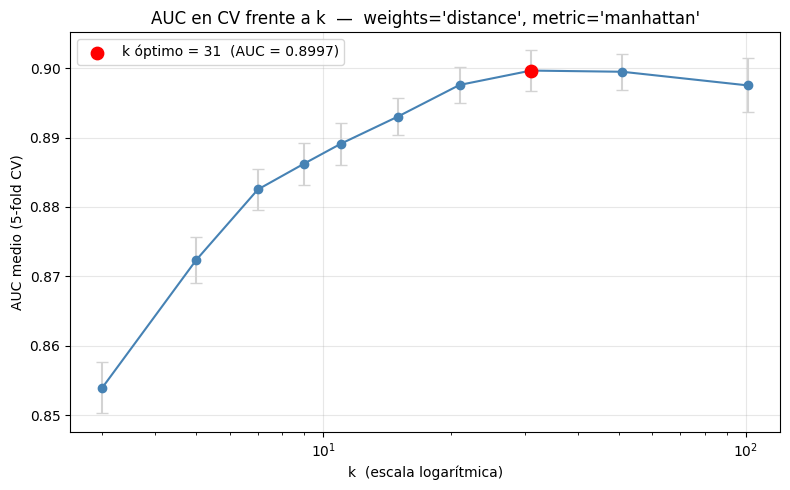

In [90]:
# Curva AUC vs k con la mejor combinación de weights y metric
best_w = knn_best_params['weights']
best_m = knn_best_params['metric']

knn_cv_df = pd.DataFrame(knn_grid.cv_results_)
mask = (
    (knn_cv_df['param_classifier__weights'] == best_w) &
    (knn_cv_df['param_classifier__metric']  == best_m)
)
curve_df = (
    knn_cv_df.loc[mask]
        .assign(k=lambda d: d['param_classifier__n_neighbors'].astype(int))
        [['k', 'mean_test_AUC', 'std_test_AUC']]
        .sort_values('k')
        .reset_index(drop=True)
)

print(f"Curva AUC vs k  (weights='{best_w}', metric='{best_m}')\n")
print(curve_df.round(4).to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(curve_df['k'], curve_df['mean_test_AUC'],
            yerr=curve_df['std_test_AUC'],
            fmt='o-', capsize=4, color='steelblue', ecolor='lightgray')

best_k   = knn_best_params['n_neighbors']
best_auc = curve_df.loc[curve_df['k'] == best_k, 'mean_test_AUC'].values[0]
ax.scatter([best_k], [best_auc], color='red', zorder=5, s=80,
           label=f'k óptimo = {best_k}  (AUC = {best_auc:.4f})')

ax.set_xscale('log')
ax.set_xlabel('k  (escala logarítmica)')
ax.set_ylabel('AUC medio (5-fold CV)')
ax.set_title(f"AUC en CV frente a k  —  weights='{best_w}', metric='{best_m}'")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### 3.6. Árbol de Clasificación

Búsqueda en cuadrícula (`GridSearchCV`) sobre:
- `criterion` ∈ {'gini', 'entropy'}
- `max_depth` ∈ {3, 5, 7, 10, 15, 20, None}
- `min_samples_split` ∈ {2, 5, 10, 20}
- `min_samples_leaf` ∈ {1, 5, 10, 20}
- `classifier__class_weight` ∈ {None, 'balanced'}

In [84]:
# Árbol de Clasificación 
dt_pipe = Pipeline([
    ('preprocessor', preprocessor_dt),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Se prueba con 448 combinaciones de hiperparámetros
dt_params = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 5, 7, 10, 15, 20, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 5, 10, 20],
    'classifier__class_weight': [None, 'balanced']
}

dt_grid = GridSearchCV(
    dt_pipe, dt_params,
    cv=cv, scoring=scoring, refit='AUC',
    n_jobs=12, verbose=1
)
dt_grid.fit(X_train, y_train)

# Mejor combinación y métricas asociadas (medias de los 5 folds)
dt_best_idx = dt_grid.best_index_
dt_best_params = {k.replace('classifier__', ''): v for k, v in dt_grid.best_params_.items()}
dt_metrics = {m: dt_grid.cv_results_[f'mean_test_{m}'][dt_best_idx] for m in scoring}

print("=== Árbol de Clasificación ===")
print(f"Mejores hiperparámetros: {dt_best_params}")
print("\nMétricas medias (5-fold CV) con la mejor combinación:")
for m, v in dt_metrics.items():
    print(f"  {m:<14}: {v:.4f}")

print("\n→ Modelo reentrenado sobre todo X_train (refit='AUC').")

# Guardar hiperparámetros en JSON
with open('dt_best_params.json', 'w') as f:
    json.dump(dt_best_params, f, indent=4)
print("→ Hiperparámetros guardados en dt_best_params.json")

Fitting 5 folds for each of 448 candidates, totalling 2240 fits
=== Árbol de Clasificación ===
Mejores hiperparámetros: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 2}

Métricas medias (5-fold CV) con la mejor combinación:
  AUC           : 0.9168
  Exactitud     : 0.8918
  Tasa de error : 0.1082
  Precisión     : 0.7442
  Sensibilidad  : 0.7687
  Especificidad : 0.9262
  F1-Score      : 0.7562

→ Modelo reentrenado sobre todo X_train (refit='AUC').
→ Hiperparámetros guardados en dt_best_params.json


#### Visualización del árbol de clasificación

Se representa el árbol entrenado limitado a profundidad $2$ para que sea legible. El color de cada nodo refleja la clase predicha y su pureza: **verde** para los nodos donde predomina *No Default* y **rojo** para los nodos donde predomina *Default*. La intensidad del color es proporcional a la proporción de la clase mayoritaria en el nodo, de modo que las regiones con clasificación más nítida aparecen con un color más saturado y las cercanas al $50\,\%$ con tonos pálidos.

AttributeError: 'NoneType' object has no attribute 'set_facecolor'

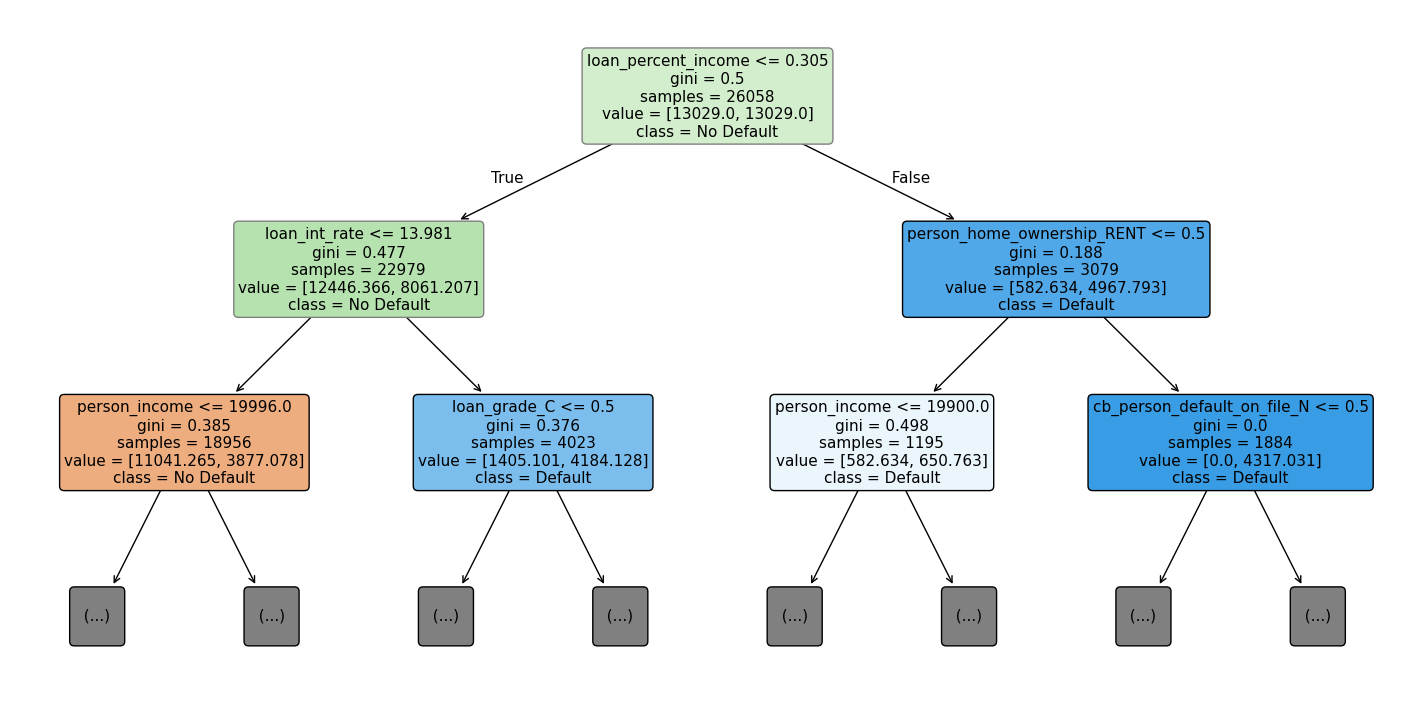

In [94]:
# Pipeline reentrenado y nombres de las variables predictoras tras el preprocesado
dt_pipe_fit = dt_grid.best_estimator_
dt_model    = dt_pipe_fit.named_steps['classifier']
dt_prep     = dt_pipe_fit.named_steps['preprocessor']

ohe_dt = dt_prep.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = list(ohe_dt.get_feature_names_out(cat_cols))
feature_names_dt  = num_cols + cat_feature_names

# Gráfico del árbol limitado a profundidad 2
fig, ax = plt.subplots(figsize=(18, 9))
artists = plot_tree(
    dt_model,
    feature_names=feature_names_dt,
    class_names=['No Default', 'Default'],
    filled=True, rounded=True, fontsize=11,
    max_depth=2, ax=ax
)

# Recoloreado: verde (No Default) ↔ rojo (Default), intensidad ∝ pureza
tree_ = dt_model.tree_
orden = []
def _dfs(n, d, max_d=2):
    orden.append(n)
    if d >= max_d or tree_.children_left[n] == tree_.children_right[n]:
        return
    _dfs(tree_.children_left[n],  d + 1, max_d)
    _dfs(tree_.children_right[n], d + 1, max_d)
_dfs(0, 0)

for ann, n in zip(artists, orden):
    p_def = tree_.value[n][0][1] / tree_.value[n][0].sum()
    if p_def >= 0.5:
        color = plt.cm.Reds(0.2 + 0.5 * (2 * (p_def - 0.5)))
    else:
        color = plt.cm.Greens(0.2 + 0.5 * (2 * (0.5 - p_def)))
    ann.get_bbox_patch().set_facecolor(color)
    ann.get_bbox_patch().set_edgecolor('gray')

ax.set_title(
    f'Árbol de Clasificación  —  profundidad real: {dt_model.get_depth()}, '
    f'nodos hoja: {dt_model.get_n_leaves()}  (visualización limitada a profundidad 2)',
    fontsize=14
)
plt.tight_layout()
plt.show()

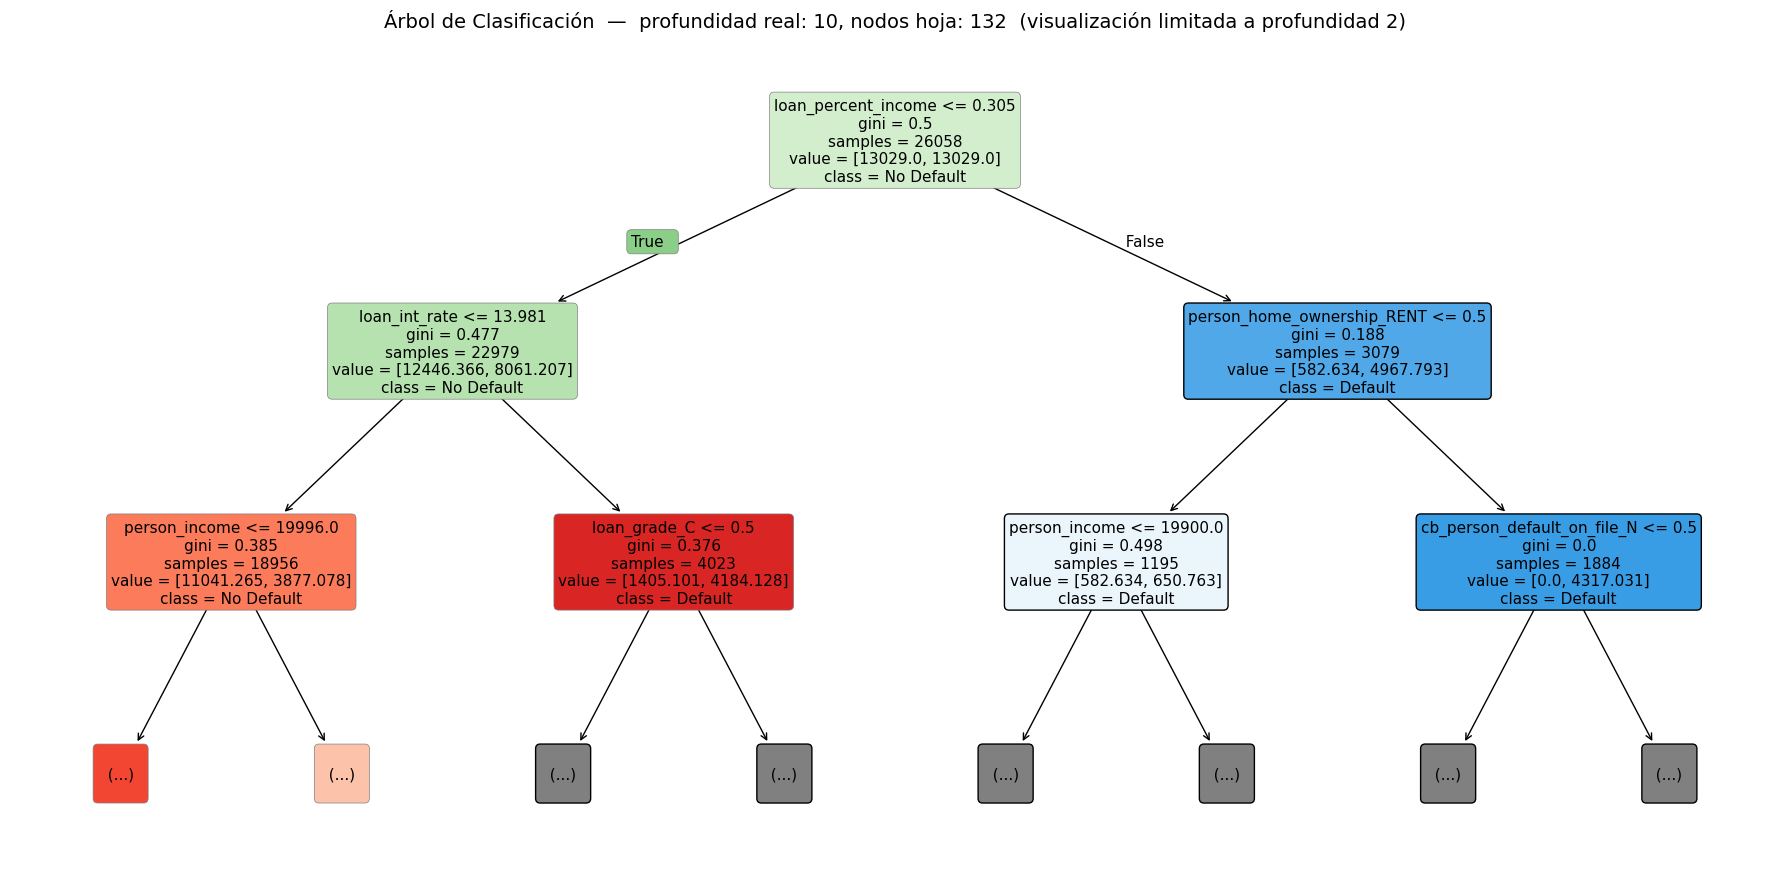

In [95]:
# Pipeline reentrenado y nombres de las variables predictoras tras el preprocesado
dt_pipe_fit = dt_grid.best_estimator_
dt_model    = dt_pipe_fit.named_steps['classifier']
dt_prep     = dt_pipe_fit.named_steps['preprocessor']

ohe_dt = dt_prep.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = list(ohe_dt.get_feature_names_out(cat_cols))
feature_names_dt  = num_cols + cat_feature_names

# Gráfico del árbol limitado a profundidad 2
fig, ax = plt.subplots(figsize=(18, 9))
artists = plot_tree(
    dt_model,
    feature_names=feature_names_dt,
    class_names=['No Default', 'Default'],
    filled=True, rounded=True, fontsize=11,
    max_depth=2, ax=ax
)

# Recorrido DFS preorden hasta profundidad 2 (mismo orden que dibuja plot_tree)
tree_ = dt_model.tree_
orden = []
def _dfs(n, d, max_d=2):
    orden.append(n)
    if d >= max_d or tree_.children_left[n] == tree_.children_right[n]:
        return
    _dfs(tree_.children_left[n],  d + 1, max_d)
    _dfs(tree_.children_right[n], d + 1, max_d)
_dfs(0, 0)

# Recoloreado: verde (No Default) ↔ rojo (Default), intensidad ∝ pureza
for ann, n in zip(artists, orden):
    p_def = tree_.value[n][0][1] / tree_.value[n][0].sum()
    if p_def >= 0.5:
        color = plt.cm.Reds(0.2 + 0.5 * (2 * (p_def - 0.5)))
    else:
        color = plt.cm.Greens(0.2 + 0.5 * (2 * (0.5 - p_def)))
    ann.set_bbox(dict(boxstyle='round,pad=0.3',
                      facecolor=color, edgecolor='gray', linewidth=0.5))

ax.set_title(
    f'Árbol de Clasificación  —  profundidad real: {dt_model.get_depth()}, '
    f'nodos hoja: {dt_model.get_n_leaves()}  (visualización limitada a profundidad 2)',
    fontsize=14
)
plt.tight_layout()
plt.show()

#### Importancia de las variables predictoras

A partir del árbol entrenado se cuantifica la importancia que asigna a cada variable predictora siguiendo cuatro pasos:

**1. Reducción ponderada de impureza de un nodo.** Para cada nodo interno $t$ con hijos izquierdo $t_L$ y derecho $t_R$, se mide cuánto mejora la pureza global del árbol gracias a esa partición:

$$\Delta i(t) = \dfrac{N_t}{N}\left[\,i(t) - \dfrac{N_{t_L}}{N_t}\,i(t_L) - \dfrac{N_{t_R}}{N_t}\,i(t_R)\right]$$

donde $i(\cdot)$ es la impureza (Gini o entropía según el criterio elegido), $N$ es el número total de muestras de entrenamiento y $N_t$, $N_{t_L}$, $N_{t_R}$ son las muestras que caen en cada nodo.

**2. Agregación por variable.** Para cada variable predictora $X_j$, su importancia bruta se obtiene sumando las reducciones de impureza de todos los nodos internos que parten por $X_j$:

$$\widetilde{\mathrm{Imp}}(X_j) = \sum_{\substack{t \in \mathcal{T}_{\text{int}} \\ v(t) = X_j}} \Delta i(t)$$

donde $\mathcal{T}_{\text{int}}$ es el conjunto de nodos internos y $v(t)$ la variable por la que se parte en el nodo $t$. Las variables que no participan en ninguna partición tienen importancia bruta $0$.

**3. Normalización.** Las importancias brutas se normalizan dividiendo por su suma para que formen una distribución (sumen $1$):

$$\mathrm{Imp}(X_j) = \dfrac{\widetilde{\mathrm{Imp}}(X_j)}{\sum_{k=1}^{p} \widetilde{\mathrm{Imp}}(X_k)}$$

Esta cantidad es precisamente el atributo `feature_importances_` que devuelve `scikit-learn`.

**4. Agregación por variable original.** Como las variables categóricas se han codificado mediante *one-hot encoding* en varias *dummies*, la importancia del paso anterior se calcula sobre las variables ya codificadas. Para una lectura más interpretable, se suman las contribuciones de todas las *dummies* de una misma variable categórica:

$$\mathrm{Imp}(X) = \sum_{c \in \mathcal{C}(X)} \mathrm{Imp}(X_c)$$

donde $\mathcal{C}(X)$ es el conjunto de categorías de $X$.

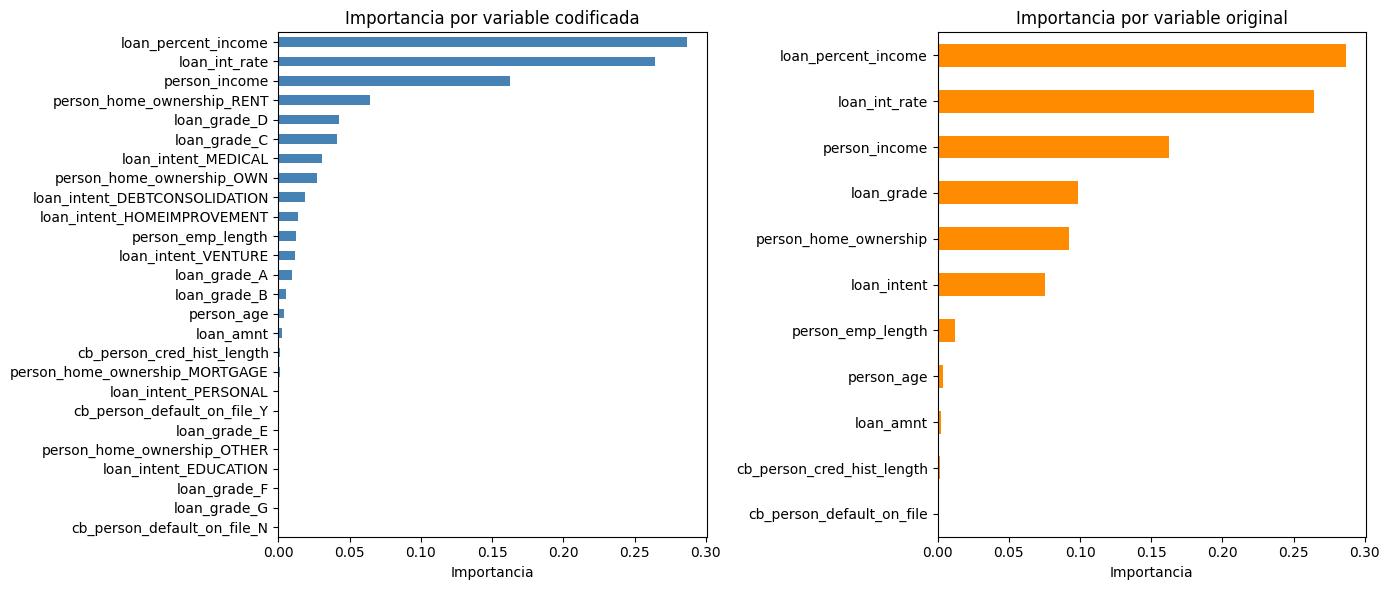

,Variable,Importancia
1,loan_percent_income,0.2866
2,loan_int_rate,0.2642
3,person_income,0.1625
4,person_home_ownership_RENT,0.0642
5,loan_grade_D,0.0423
6,loan_grade_C,0.0414
7,loan_intent_MEDICAL,0.0307
8,person_home_ownership_OWN,0.0269
9,loan_intent_DEBTCONSOLIDATION,0.0189
10,loan_intent_HOMEIMPROVEMENT,0.0134


In [93]:
# Importancia de cada variable predictora codificada
imp_df = pd.DataFrame({
    'Variable':    feature_names_dt,
    'Importancia': dt_model.feature_importances_.round(4)
}).sort_values('Importancia', ascending=False).reset_index(drop=True)
imp_df.index += 1

# Agregación por variable original (suma de las dummies de cada categórica)
def variable_origen(nombre):
    for c in cat_cols:
        if nombre.startswith(c + '_'):
            return c
    return nombre

imp_agg = (
    imp_df.assign(**{'Variable original': imp_df['Variable'].map(variable_origen)})
          .groupby('Variable original', as_index=False)['Importancia'].sum()
          .sort_values('Importancia', ascending=False)
          .reset_index(drop=True)
)
imp_agg.index += 1
imp_agg['Importancia'] = imp_agg['Importancia'].round(4)

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

imp_df.plot.barh(x='Variable', y='Importancia', ax=axes[0],
                 legend=False, color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Importancia por variable codificada')
axes[0].set_xlabel('Importancia'); axes[0].set_ylabel('')

imp_agg.plot.barh(x='Variable original', y='Importancia', ax=axes[1],
                  legend=False, color='darkorange')
axes[1].invert_yaxis()
axes[1].set_title('Importancia por variable original')
axes[1].set_xlabel('Importancia'); axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

imp_df  # Tabla con la importancia por variable codificada

### 3.7.7. Resumen comparativo

In [87]:
# Tabla comparativa con las métricas medias en 5-fold CV
summary = pd.DataFrame({
    'Regresión Logística':   lr_metrics,
    'K-NN':                  knn_metrics,
    'Árbol de Clasificación': dt_metrics
}).T.round(4)

summary

,AUC,Exactitud,Tasa de error,Precisión,Sensibilidad,Especificidad,F1-Score
Regresión Logística,0.8541,0.8485,0.1515,0.7515,0.4562,0.9580,0.5675
K-NN,0.8997,0.8977,0.1023,0.9196,0.5821,0.9858,0.7129
Árbol de Clasificación,0.9168,0.8918,0.1082,0.7442,0.7687,0.9262,0.7562


## 4. Random Forest

## 5. Adaboost y Gradient Boosting

## 6. Voting

## 7. Stacking

## 8. Comparativa final y evaluación en Test